# EEG Channel Hierarchical Clustering
**Dataset:** CHB-MIT chb01 · segment 2980–3010 s (pre-ictal)  
**Input:** `inter_to_ict_chb01_03_2980_3010_adjacency_sparse.npz`  
**Structure:** 23 EEG channels × 7,680 timepoints (30 s @ 256 Hz)  

---
The pipeline has four steps:
1. Load the sparse adjacency matrix
2. Extract a temporal activity profile per channel
3. Compute a 23×23 Pearson correlation matrix and run Ward hierarchical clustering
4. Plot the correlation heatmap, then the dendrogram

## Imports

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration

In [5]:
# Path to the .npz file — update this if it lives elsewhere
NPZ_PATH = "/Users/antoniaspoerk/Desktop/Digital Neuroscience /Social Media Analytics/epilepsy_pediatrics_EEG/data/graphs/adjacency_sparse/inter_to_ict_chb01_03_2980_3010_adjacency_sparse.npz"

N_CHANNELS   = 23
N_TIMEPOINTS = 7680   # 30 s x 256 Hz

# CHB-MIT chb01 channel montage (23 channels)
CHANNEL_NAMES = [
    "FP1-F7", "F7-T7",  "T7-P7",  "P7-O1",
    "FP1-F3", "F3-C3",  "C3-P3",  "P3-O1",
    "FP2-F4", "F4-C4",  "C4-P4",  "P4-O2",
    "FP2-F8", "F8-T8",  "T8-P8",  "P8-O2",
    "FZ-CZ",  "CZ-PZ",
    "P7-T7",  "T7-FT9", "FT9-FT10", "FT10-T8",
    "T8-P8-1"
]

# Colour palette
BG             = "#0f1117"
PANEL_BG       = "#1a1d27"
TEXT           = "#e0e0e0"
CLUSTER_COLORS = ["#7c6af7", "#f7936a", "#5ecfb1", "#e05c97", "#f5d547"]

## Step 1 — Load the sparse adjacency matrix

In [6]:
mat = sp.load_npz(NPZ_PATH)
print(f"Shape      : {mat.shape}")
print(f"Non-zeros  : {mat.nnz:,}")
print(f"Density    : {mat.nnz / mat.shape[0]**2:.2e}")

Shape      : (176640, 176640)
Non-zeros  : 3,956,402
Density    : 1.27e-04


## Step 2 — Extract temporal activity profile per channel

Each channel occupies a contiguous block of `N_TIMEPOINTS` rows and columns.
The **intra-channel block** (same channel, different timepoints) holds small float weights
that encode temporal similarity within that channel.
Summing edge weights per timepoint gives a 1-D activity signature for each channel.

In [7]:
ch_temporal = np.zeros((N_CHANNELS, N_TIMEPOINTS), dtype=np.float64)

for ch in range(N_CHANNELS):
    s, e = ch * N_TIMEPOINTS, (ch + 1) * N_TIMEPOINTS
    block = mat[s:e, s:e]   # intra-channel block
    ch_temporal[ch] = np.array(block.sum(axis=1)).flatten()

print(f"Profile matrix shape: {ch_temporal.shape}  (channels x timepoints)")

Profile matrix shape: (23, 7680)  (channels x timepoints)


## Step 3 — Correlation matrix + Ward hierarchical clustering

In [8]:
# 23x23 Pearson correlation between channel profiles
corr = np.corrcoef(ch_temporal)
print(f"Correlation range: {corr[corr < 1].min():.3f}  –  1.0")

# Convert to distance and cluster
dist_condensed = squareform(1.0 - corr, checks=False)
linkage        = sch.linkage(dist_condensed, method="ward")

# Leaf order for reordering the heatmap
dend_info      = sch.dendrogram(linkage, no_plot=True)
order          = dend_info["leaves"]
corr_ordered   = corr[np.ix_(order, order)]
labels_ordered = [CHANNEL_NAMES[i] for i in order]

print("Clustering complete.")

Correlation range: 0.063  –  1.0
Clustering complete.


## Plot 1 — Channel Correlation Heatmap

Channels are **reordered by cluster membership** so that similar channels appear next to each other.
Red = high correlation, blue = low correlation.

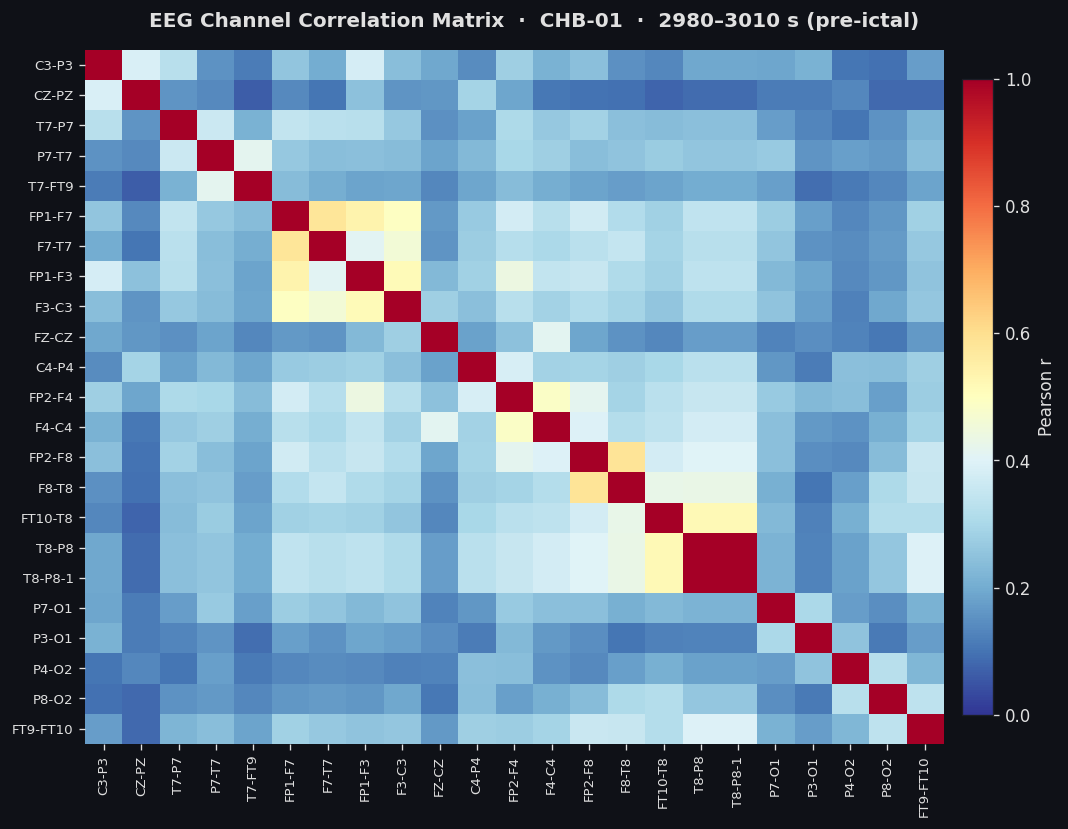

In [9]:
fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
fig.suptitle(
    "EEG Channel Correlation Matrix  ·  CHB-01  ·  2980–3010 s (pre-ictal)",
    color=TEXT, fontsize=12, fontweight="bold", y=0.98
)
ax.set_facecolor(PANEL_BG)
for spine in ax.spines.values():
    spine.set_visible(False)

im = ax.imshow(corr_ordered, cmap="RdYlBu_r", vmin=0, vmax=1,
               aspect="auto", interpolation="nearest")
ax.set_xticks(range(N_CHANNELS))
ax.set_yticks(range(N_CHANNELS))
ax.set_xticklabels(labels_ordered, rotation=90, fontsize=8, color=TEXT)
ax.set_yticklabels(labels_ordered, fontsize=8, color=TEXT)
ax.tick_params(colors=TEXT)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Pearson r", color=TEXT, fontsize=10)
cbar.ax.yaxis.set_tick_params(color=TEXT, labelcolor=TEXT)
cbar.outline.set_edgecolor(PANEL_BG)

plt.tight_layout()
plt.show()

## Plot 2 — Dendrogram

Each coloured branch is a distinct cluster. Read right-to-left:
channels that merge near **distance 0** are nearly identical;
channels that only merge near **distance 1.2** are functionally independent.

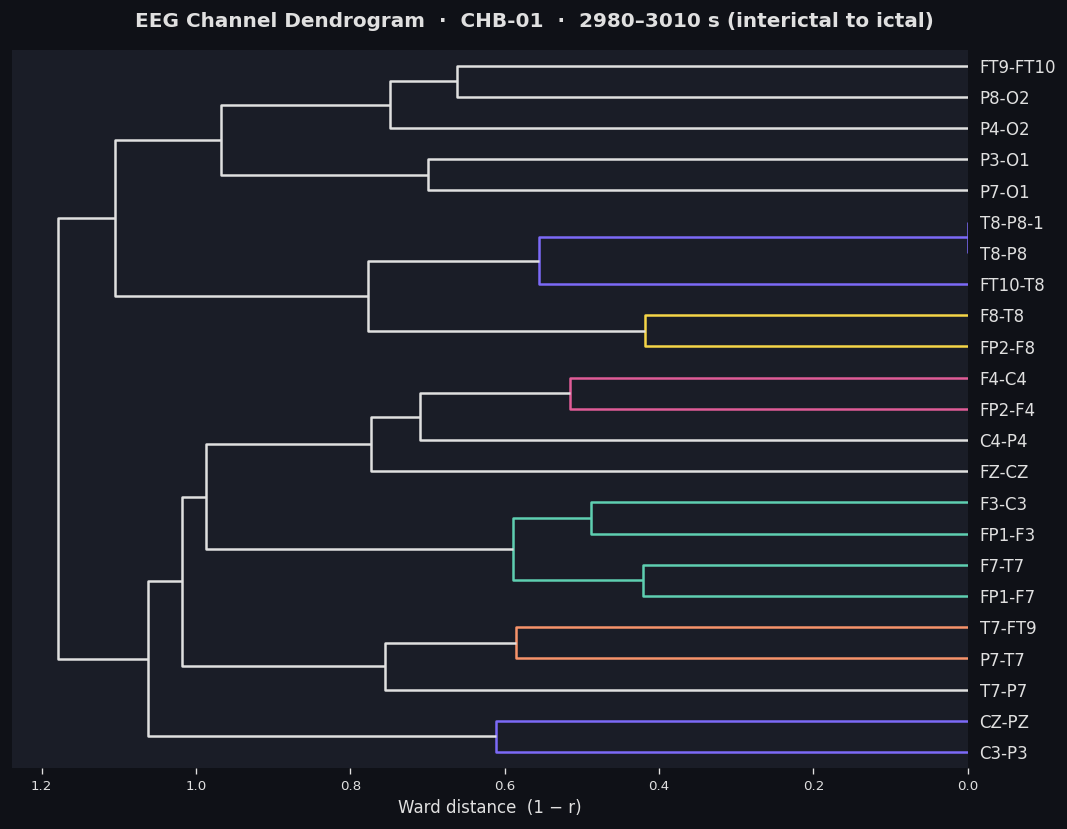

In [11]:
sch.set_link_color_palette(CLUSTER_COLORS)

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
fig.suptitle(
    "EEG Channel Dendrogram  ·  CHB-01  ·  2980–3010 s (interictal to ictal)",
    color=TEXT, fontsize=12, fontweight="bold", y=0.98
)
ax.set_facecolor(PANEL_BG)
for spine in ax.spines.values():
    spine.set_visible(False)

sch.dendrogram(
    linkage,
    labels=CHANNEL_NAMES,
    orientation="left",
    ax=ax,
    color_threshold=0.55 * linkage[-1, 2],
    above_threshold_color=TEXT,
    leaf_font_size=10,
)

ax.tick_params(axis="x", colors=TEXT, labelsize=8)
ax.tick_params(axis="y", colors=TEXT, labelsize=10)
ax.set_xlabel("Ward distance  (1 − r)", color=TEXT, fontsize=10)

for line in ax.get_lines():
    line.set_linewidth(2.0)

plt.tight_layout()
plt.show()